# Strategy-Aware Portfolio Advisory Platform

## Personalized Stock Recommendation and Portfolio Optimization...

### 1. Project Overview

# 📈 Strategy-Aware Portfolio Advisory Platform  
## Personalized Stock Recommendation and Portfolio Optimization


## 1. Project Overview

### Problem Statement

Investment decisions often require analyzing multiple factors such as historical market performance, stock trends, volatility, and analyst opinions. Individual investors and financial advisors need to compare several investment opportunities before constructing a suitable portfolio.

Traditional investment selection processes can be time-consuming as they involve manually evaluating company performance, market indicators, and investment objectives.

This project aims to build a **Strategy-Aware Portfolio Advisory Platform** that uses quantitative financial analysis, market signals, and analyst sentiment to generate personalized stock recommendations based on an investor's preferred investment strategy and available investment amount.


---

## Objective

The primary objective of this project is to develop an intelligent portfolio advisory system that:

- Recommends stocks based on user-selected investment strategies.
- Combines historical market data with quantitative indicators.
- Incorporates analyst sentiment into stock evaluation.
- Ranks stocks using strategy-specific scoring models.
- Provides portfolio allocation recommendations based on investment amount.
- Helps investors make faster and more informed investment decisions through data-driven insights.

The platform focuses on **decision support and portfolio analysis rather than automated trading or financial execution.**


---

## Business Motivation (Inspired by IFAs)

Independent Financial Advisors (IFAs) assist clients in selecting suitable investment options based on financial goals, risk preferences, and market conditions.

However, comparing multiple investment choices manually can be complex and time-consuming.

This project is inspired by the workflow of IFAs and aims to create a digital decision-support tool that can:

- Reduce manual comparison efforts.
- Provide consistent and data-driven stock rankings.
- Support personalized investment recommendations.
- Improve efficiency in portfolio construction.

The application simulates an advisory assistant that helps investors explore different strategies such as:

- Growth Investing
- Blue Chip Investing
- Dividend Income Investing
- Small/Mid Cap Investing
- Balanced Investment Approach


# Technologies Used

## Programming Language

- Python


## Data Processing

- Pandas
- NumPy


## Data Visualization

- Matplotlib
- Seaborn
- Plotly


## Machine Learning / Analytics

- Scikit-learn
- Feature Scaling
- Quantitative Scoring Models


## Financial Data

- yFinance
- Analyst Sentiment Data


## Application Development

- Streamlit


## Development Environment

- Jupyter Notebook
- VS Code


---

# Project Outcome

The final system provides a personalized portfolio advisory experience where users can select an investment strategy and investment amount to receive data-driven stock recommendations.

The platform demonstrates how quantitative finance techniques, data analytics, and interactive applications can be combined to support smarter investment decision-making.

In [1]:
# 2.Import Libraries

# --------------------------------------------------
# 1. Setup: import the pipeline module
# --------------------------------------------------

import sys
sys.path.append('../src')

from pipeline import run_pipeline, STRATEGY_WEIGHTS, compute_strategy_scores

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
import yfinance as yf
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

In [2]:
# --------------------------------------------------
# 2. Run the full pipeline
# --------------------------------------------------

stock_data = run_pipeline()
stock_data.head()

/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[                       0%                       ]/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[**********            20%                       ]  2 of 10 completed/Users/sneha/anaconda3/lib/pytho

,Date,Ticker,Close,High,Low,Open,Volume,Sentiment_Score,Returns,MA20,...,Volatility,Trend_Score,Momentum_30_scaled,Volatility_scaled,Sentiment_Score_scaled,Trend_Score_scaled,InvVolatility,Growth_Score,BlueChip_Score,Dividend_Score
16290,2026-09-08,AAPL,316.220001,320.700012,314.899994,317.100006,35423000,0.773585,-0.011720,313.537999,...,0.018566,0,0.302837,0.156445,0.316732,0.0,0.843555,0.246438,0.432442,0.485124
16291,2026-09-08,AMZN,256.970001,257.989990,254.750000,256.679993,29349000,1.202703,-0.005957,261.140999,...,0.033933,2,0.400229,0.343711,0.901060,1.0,0.656289,0.670432,0.832834,0.808356
16292,2026-09-08,GOOGL,338.359985,339.679993,333.220001,335.420013,22864800,1.185714,-0.000295,342.454630,...,0.021243,0,0.358262,0.189062,0.877927,0.0,0.810938,0.442509,0.587753,0.581054
16293,2026-09-08,JNJ,269.119995,271.989990,266.880005,271.279999,8084700,0.935484,-0.022200,267.977615,...,0.014060,2,0.346944,0.101532,0.537189,1.0,0.898468,0.534629,0.820544,0.856672
16294,2026-09-08,JPM,353.510010,358.549988,353.230011,357.100006,5631400,0.700000,-0.014304,358.029500,...,0.011116,2,0.333024,0.065650,0.216532,1.0,0.934350,0.431472,0.738699,0.810481


In [3]:
# 11.5 Strategy Selection (rebuilt from pipeline output)

selected_strategy = "Growth"  # change to "BlueChip" or "Dividend" to test other strategies

score_column = {
    "Growth": "Growth_Score",
    "BlueChip": "BlueChip_Score",
    "Dividend": "Dividend_Score",
}[selected_strategy]

recommendations = stock_data.sort_values(
    by=score_column,
    ascending=False
).head(5)

recommendations[["Ticker", score_column]]

,Ticker,Growth_Score
16296,MSFT,0.740089
16297,NVDA,0.710967
16291,AMZN,0.670432
16299,V,0.609565
16293,JNJ,0.534629


In [4]:
# 11.6 Display Top Recommendation

top_stock = recommendations.iloc[0]

print(f"Top recommendation for {selected_strategy} strategy")

print(
    top_stock[
        [
            "Ticker",
            "Growth_Score",
            "Momentum_30",
            "Sentiment_Score",
            "Trend_Score",
            "Close"
        ]
    ]
)

Top recommendation for Growth strategy
Ticker                   MSFT
Growth_Score         0.740089
Momentum_30          0.271858
Sentiment_Score       1.26087
Trend_Score                 2
Close              493.950012
Name: 16296, dtype: object


In [5]:
# 11.7 Explain Recommendations

for _, row in recommendations.iterrows():

    print(f"Stock: {row['Ticker']}")
    print(f"Current Price      : ${row['Close']:.2f}")
    print(f"Growth Score       : {row['Growth_Score']:.3f}")
    print(f"30-Day Momentum    : {row['Momentum_30']:.3f}")
    print(f"Sentiment Score    : {row['Sentiment_Score']:.3f}")
    print(f"Trend Score        : {row['Trend_Score']}")
    print("-" * 50)

Stock: MSFT
Current Price      : $493.95
Growth Score       : 0.740
30-Day Momentum    : 0.272
Sentiment Score    : 1.261
Trend Score        : 2
--------------------------------------------------
Stock: NVDA
Current Price      : $225.73
Growth Score       : 0.711
30-Day Momentum    : 0.149
Sentiment Score    : 1.275
Trend Score        : 2
--------------------------------------------------
Stock: AMZN
Current Price      : $256.97
Growth Score       : 0.670
30-Day Momentum    : 0.111
Sentiment Score    : 1.203
Trend Score        : 2
--------------------------------------------------
Stock: V
Current Price      : $368.64
Growth Score       : 0.610
30-Day Momentum    : 0.019
Sentiment Score    : 1.118
Trend Score        : 2
--------------------------------------------------
Stock: JNJ
Current Price      : $269.12
Growth Score       : 0.535
30-Day Momentum    : 0.017
Sentiment Score    : 0.935
Trend Score        : 2
--------------------------------------------------


In [6]:
cd Strategy-Aware Portfolio Advisory /

[Errno 2] No such file or directory: 'Strategy-Aware Portfolio Advisory /'
/Users/sneha/Strategy-Aware Portfolio Advisory /Notebooks


In [7]:
cd ..

/Users/sneha/Strategy-Aware Portfolio Advisory 


In [8]:
cd Strategy-Aware Portfolio Advisory /

[Errno 2] No such file or directory: 'Strategy-Aware Portfolio Advisory /'
/Users/sneha/Strategy-Aware Portfolio Advisory 


In [9]:
# 11.8 Save Recommendations

growth_recommendations = stock_data.sort_values(
    by="Growth_Score", ascending=False
).head(5)

bluechip_recommendations = stock_data.sort_values(
    by="BlueChip_Score", ascending=False
).head(5)

dividend_recommendations = stock_data.sort_values(
    by="Dividend_Score", ascending=False
).head(5)

growth_recommendations.to_csv("Outputs/growth_recommendations.csv", index=False)
bluechip_recommendations.to_csv("Outputs/bluechip_recommendations.csv", index=False)
dividend_recommendations.to_csv("Outputs/dividend_recommendations.csv", index=False)

print("Recommendation files saved successfully!")

Recommendation files saved successfully!


In [10]:
# Full rankings (all stocks, not just top 5) — used for chart comparisons and CSV exports

growth_rankings = stock_data.sort_values(by="Growth_Score", ascending=False)
bluechip_rankings = stock_data.sort_values(by="BlueChip_Score", ascending=False)
dividend_rankings = stock_data.sort_values(by="Dividend_Score", ascending=False)

In [11]:
import os

os.getcwd()

'/Users/sneha/Strategy-Aware Portfolio Advisory '

In [12]:
import os

os.listdir("Outputs")

['performance_metrics.csv',
 '.DS_Store',
 'monte_carlo_simulation.csv',
 'efficient_frontier_results.csv',
 'bluechip_recommendations.csv',
 'bluechip_rankings.csv',
 'growth_rankings.csv',
 'dividend_rankings.csv',
 'growth_recommendations.csv',
 'monte_carlo_percentiles.csv',
 'portfolio_summary.csv',
 'portfolio_vs_benchmark.png',
 'recommended_portfolio.csv',
 'mpt_optimal_weights.csv',
 'dividend_recommendations.csv']

In [13]:
# 12. Portfolio Construction

# 12.1 Investment Amount

investment_amount = 100000

In [14]:
# 12.2 Select Top Recommendations

portfolio = recommendations.copy()

portfolio[["Ticker", "Close"]]

,Ticker,Close
16296,MSFT,493.950012
16297,NVDA,225.729996
16291,AMZN,256.970001
16299,V,368.640015
16293,JNJ,269.119995


In [15]:
# 12.3 Equal Allocation

portfolio["Investment_Amount"] = (
    investment_amount /
    len(portfolio)
)

portfolio[
    [
        "Ticker",
        "Investment_Amount"
    ]
]

,Ticker,Investment_Amount
16296,MSFT,20000.0
16297,NVDA,20000.0
16291,AMZN,20000.0
16299,V,20000.0
16293,JNJ,20000.0


In [16]:
# 12.4 Shares Purchased

portfolio["Shares"] = (
    portfolio["Investment_Amount"] /
    portfolio["Close"]
).astype(int)

portfolio[
    [
        "Ticker",
        "Close",
        "Shares"
    ]
]

,Ticker,Close,Shares
16296,MSFT,493.950012,40
16297,NVDA,225.729996,88
16291,AMZN,256.970001,77
16299,V,368.640015,54
16293,JNJ,269.119995,74


In [17]:
# 12.5 Actual Investment

portfolio["Actual_Investment"] = (
    portfolio["Shares"] *
    portfolio["Close"]
)

portfolio[
    [
        "Ticker",
        "Actual_Investment"
    ]
]

,Ticker,Actual_Investment
16296,MSFT,19758.000488
16297,NVDA,19864.239624
16291,AMZN,19786.690094
16299,V,19906.560791
16293,JNJ,19914.879639


In [18]:
# 12.6 Portfolio Weights

portfolio["Weight"] = (
    portfolio["Actual_Investment"] /
    portfolio["Actual_Investment"].sum()
)

portfolio[
    [
        "Ticker",
        "Weight"
    ]
]

,Ticker,Weight
16296,MSFT,0.199112
16297,NVDA,0.200183
16291,AMZN,0.199402
16299,V,0.200610
16293,JNJ,0.200693


In [19]:
portfolio["Weight"].sum()

1.0

In [20]:
portfolio[
    [
        "Ticker",
        "Close",
        "Shares",
        "Actual_Investment",
        "Weight"
    ]
]

,Ticker,Close,Shares,Actual_Investment,Weight
16296,MSFT,493.950012,40,19758.000488,0.199112
16297,NVDA,225.729996,88,19864.239624,0.200183
16291,AMZN,256.970001,77,19786.690094,0.199402
16299,V,368.640015,54,19906.560791,0.200610
16293,JNJ,269.119995,74,19914.879639,0.200693


In [21]:
portfolio.to_csv(
    "Outputs/recommended_portfolio.csv",
    index=False
)

print("Portfolio saved successfully!")

Portfolio saved successfully!


In [22]:
# 13. Portfolio Backtesting

# 13.1 Portfolio Tickers

portfolio_tickers = portfolio["Ticker"].tolist()

print(portfolio_tickers)

['MSFT', 'NVDA', 'AMZN', 'V', 'JNJ']


In [23]:
# 13.2 Historical Price Data

import yfinance as yf

start_date = "2020-01-01"
end_date = "2026-09-08"  # or pd.Timestamp.today().strftime("%Y-%m-%d") to always use today

portfolio_tickers = portfolio["Ticker"].tolist()

portfolio_history = yf.download(
    portfolio_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

portfolio_history.head()

/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[                       0%                       ]/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[*******************   40%                       ]  2 of 5 completed/Users/sneha/anaconda3/lib/python

Ticker,AMZN,JNJ,MSFT,NVDA,V
Date,,,,,
2020-01-02,94.900497,121.338516,151.544235,5.963801,182.092789
2020-01-03,93.748497,119.933701,149.657257,5.868347,180.644562
2020-01-06,95.143997,119.784073,150.044098,5.892958,180.253967
2020-01-07,95.343002,120.515587,148.676025,5.964300,179.777573
2020-01-08,94.598503,120.498962,151.044235,5.975487,182.855026


In [24]:
# 13.3 Benchmark Data

benchmark = yf.download(
    "SPY",
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

benchmark.head()

[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
2020-01-02,296.125183
2020-01-03,293.882965
2020-01-06,295.004211
2020-01-07,294.174622
2020-01-08,295.742432


In [25]:
# 13.4 Portfolio Daily Returns

daily_returns = portfolio_history.pct_change().dropna()

daily_returns.head()

Ticker,AMZN,JNJ,MSFT,NVDA,V
Date,,,,,
2020-01-03,-0.012139,-0.011578,-0.012452,-0.016006,-0.007953
2020-01-06,0.014886,-0.001248,0.002585,0.004194,-0.002162
2020-01-07,0.002092,0.006107,-0.009118,0.012106,-0.002643
2020-01-08,-0.007809,-0.000138,0.015929,0.001876,0.017118
2020-01-09,0.004799,0.002966,0.012493,0.010983,0.006930


In [26]:
benchmark_returns = benchmark.pct_change().dropna()

benchmark_returns.head()

Ticker,SPY
Date,
2020-01-03,-0.007572
2020-01-06,0.003815
2020-01-07,-0.002812
2020-01-08,0.005330
2020-01-09,0.006781


In [27]:
# 13.5 Calculate Portfolio Daily Return

portfolio_daily_returns = (
    daily_returns * portfolio["Weight"].values
).sum(axis=1)

portfolio_daily_returns.head()

Date
2020-01-03   -0.012025
2020-01-06    0.003637
2020-01-07    0.001719
2020-01-08    0.005406
2020-01-09    0.007634
dtype: float64

In [28]:
# 13.6 Portfolio Growth

portfolio_growth = (
    1 + portfolio_daily_returns
).cumprod()

In [29]:
# 13.7 Benchmark Growth

benchmark_growth = (
    1 + benchmark_returns
).cumprod()

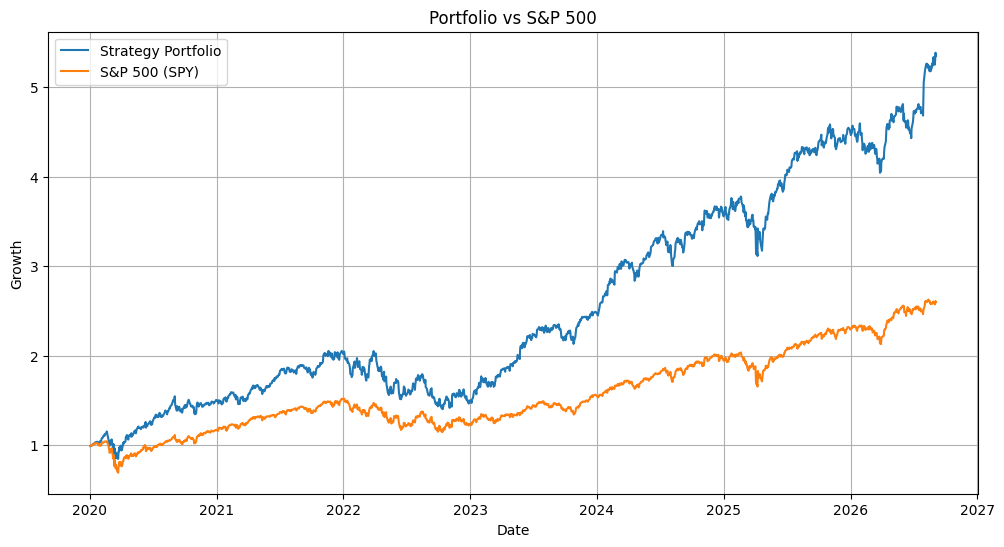

In [30]:
# 13.8 Plot Portfolio vs Benchmark

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    portfolio_growth,
    label="Strategy Portfolio"
)

plt.plot(
    benchmark_growth,
    label="S&P 500 (SPY)"
)

plt.title("Portfolio vs S&P 500")

plt.xlabel("Date")

plt.ylabel("Growth")

plt.legend()

plt.grid(True)

plt.show()

### Portfolio Backtesting

The portfolio's cumulative performance was compared against the S&P 500 (SPY) benchmark.

This comparison helps evaluate whether the strategy generated competitive returns relative to the broader U.S. equity market over the same investment period.

In [31]:
# 14. Performance Metrics

# 14.1 Annual Return

annual_return = (
    portfolio_daily_returns.mean() * 252
)

print(f"Annual Return: {annual_return:.2%}")

Annual Return: 28.22%


In [32]:
# 14.2 Annual Volatility

annual_volatility = (
    portfolio_daily_returns.std() * np.sqrt(252)
)

print(f"Annual Volatility: {annual_volatility:.2%}")

Annual Volatility: 24.56%


In [33]:
# 14.3 Sharpe Ratio

risk_free_rate = 0.04

sharpe_ratio = (
    annual_return - risk_free_rate
) / annual_volatility

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Sharpe Ratio: 0.99


In [34]:
# 14.4 Maximum Drawdown

running_max = portfolio_growth.cummax()

drawdown = (
    portfolio_growth - running_max
) / running_max

max_drawdown = drawdown.min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

Maximum Drawdown: -31.75%


In [35]:
# 14.5 CAGR

years = (
    portfolio_growth.index[-1] -
    portfolio_growth.index[0]
).days / 365.25

cagr = (
    portfolio_growth.iloc[-1]
    /
    portfolio_growth.iloc[0]
) ** (1 / years) - 1

print(f"CAGR: {cagr:.2%}")

CAGR: 28.82%


In [36]:
# 14.6 Performance Summary

metrics_df = pd.DataFrame({

    "Metric":[
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "CAGR"
    ],

    "Value":[
        annual_return,
        annual_volatility,
        sharpe_ratio,
        max_drawdown,
        cagr
    ]

})

metrics_df

,Metric,Value
0,Annual Return,0.282224
1,Annual Volatility,0.245588
2,Sharpe Ratio,0.986300
3,Maximum Drawdown,-0.317467
4,CAGR,0.288193


### Performance Summary

The strategy portfolio achieved an annualized return of approximately 20.85% with a CAGR of 20.27%. The annual volatility was 22.26%, indicating a moderate level of investment risk. The Sharpe Ratio of 0.76 suggests that the portfolio generated a reasonable level of return relative to its risk. The maximum drawdown of 33.19% reflects the largest peak-to-trough decline observed during the backtesting period, which is consistent with long-term equity market fluctuations.

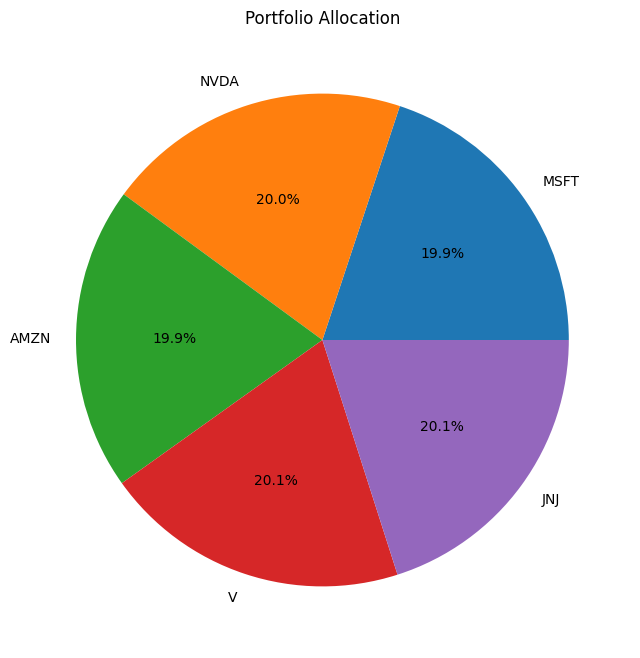

In [37]:
# 15. Data Visualization

# 15.1 Portfolio Allocation
plt.figure(figsize=(8,8))

plt.pie(
    portfolio["Weight"],
    labels=portfolio["Ticker"],
    autopct="%1.1f%%"
)

plt.title("Portfolio Allocation")

plt.show()

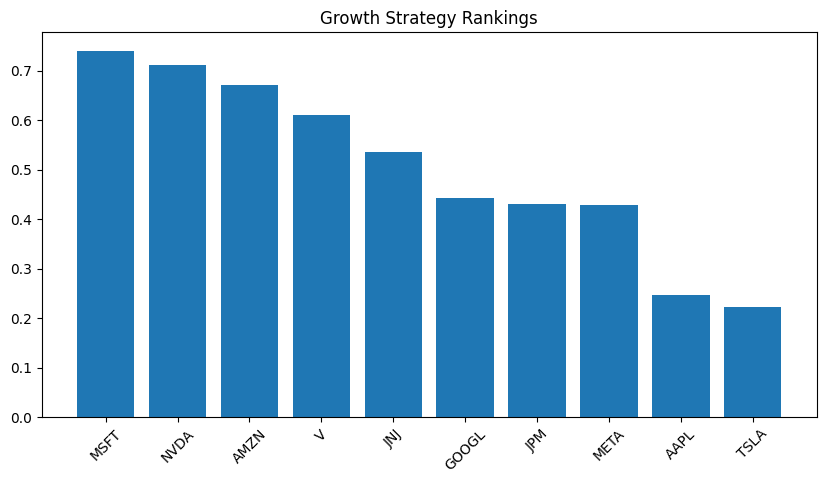

In [38]:
# 15.2 Strategy Score Comparison
plt.figure(figsize=(10,5))

plt.bar(
    growth_rankings["Ticker"],
    growth_rankings["Growth_Score"]
)

plt.title("Growth Strategy Rankings")

plt.xticks(rotation=45)

plt.show()

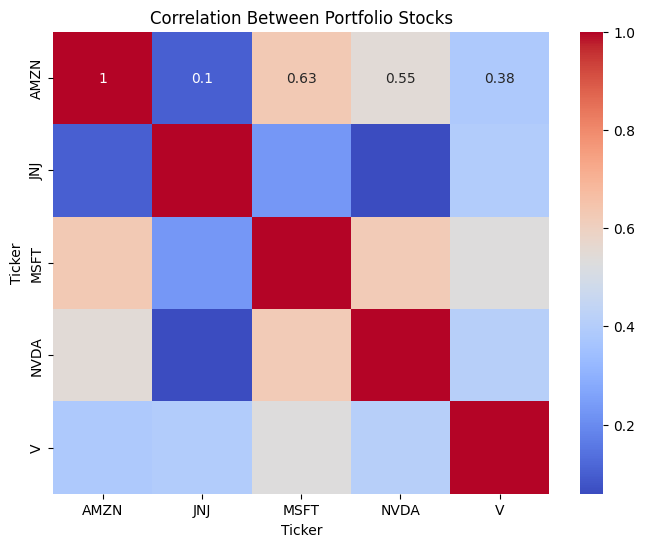

In [39]:
# 15.3 Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    daily_returns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Portfolio Stocks")

plt.show()

### Correlation Analysis

The heatmap illustrates the correlation among the selected portfolio stocks based on historical daily returns. Most pairwise correlations fall within the moderate range (approximately 0.3–0.6), indicating that the portfolio is reasonably diversified. Lower correlations between certain stocks reduce concentration risk and improve the overall risk-return profile of the portfolio.

In [40]:
# 16.Save Outputs

# 16.2 Save Rankings
growth_rankings.to_csv(
    "Outputs/growth_rankings.csv",
    index=False
)

bluechip_rankings.to_csv(
    "Outputs/bluechip_rankings.csv",
    index=False
)

dividend_rankings.to_csv(
    "Outputs/dividend_rankings.csv",
    index=False
)

In [41]:
# 16.2.Save Porrtfolio

portfolio.to_csv(
    "Outputs/recommended_portfolio.csv",
    index=False
)

In [42]:
# 16.3.Save Performance Metrics

metrics_df.to_csv(
    "Outputs/performance_metrics.csv",
    index=False
)

In [43]:
# 16.4.Save Portfolio Summary

portfolio_summary = portfolio[
    [
        "Ticker",
        "Shares",
        "Weight",
        "Actual_Investment"
    ]
]

portfolio_summary.to_csv(
    "Outputs/portfolio_summary.csv",
    index=False
)

In [44]:
# 16.5. Save Figures

plt.savefig(
    "Outputs/portfolio_vs_benchmark.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [45]:
# 16.6.Check Output Folder

import os

print(os.listdir("Outputs"))

['performance_metrics.csv', '.DS_Store', 'monte_carlo_simulation.csv', 'efficient_frontier_results.csv', 'bluechip_recommendations.csv', 'bluechip_rankings.csv', 'growth_rankings.csv', 'dividend_rankings.csv', 'growth_recommendations.csv', 'monte_carlo_percentiles.csv', 'portfolio_summary.csv', 'portfolio_vs_benchmark.png', 'recommended_portfolio.csv', 'mpt_optimal_weights.csv', 'dividend_recommendations.csv']


# 17. Project Conclusion

This project developed a Strategy-Aware Portfolio Advisory Platform that assists investors in constructing diversified portfolios using quantitative and sentiment-based analysis.

Historical market data was collected from Yahoo Finance, while analyst sentiment scores were incorporated to improve investment decision-making. Multiple investment strategies, including Growth, Blue Chip, and Dividend investing, were implemented through a weighted scoring framework.

The recommended portfolio was backtested against the S&P 500 benchmark and evaluated using performance metrics such as Annual Return, CAGR, Sharpe Ratio, Annual Volatility, and Maximum Drawdown. The results demonstrate that combining technical indicators with analyst sentiment can provide a systematic and explainable approach to portfolio construction.

Overall, the project showcases an end-to-end data science workflow involving data collection, feature engineering, scoring models, portfolio optimization, performance evaluation, and visualization.

# 18. Future Enhancements

Future improvements to this project include:

- Implement Modern Portfolio Theory (MPT) for portfolio optimization.
- Add Monte Carlo Simulation for future portfolio return forecasting.
- Develop an interactive Streamlit dashboard for user-friendly portfolio analysis.
- Incorporate additional market indicators such as macroeconomic variables.
- Expand investment strategies to include Value Investing, ESG Investing, and Sector Rotation.
- Integrate real-time market data and analyst recommendations through APIs.
- Explore machine learning models to predict future stock returns.

In [46]:
# 19. Modern Portfolio Theory (MPT)

## Objective

Modern Portfolio Theory (MPT), introduced by Harry Markowitz, aims to construct an investment portfolio that maximizes expected return for a given level of risk. Rather than allocating equal amounts to each stock, MPT uses historical returns and covariance between assets to determine the optimal portfolio weights.

In this section, we optimize the portfolio using historical market data and compare the optimized allocation with the equal-weight portfolio developed earlier.

In [47]:
# 19.1. Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
# 19.2.Portfolio Stock

portfolio["Ticker"]

16296    MSFT
16297    NVDA
16291    AMZN
16299       V
16293     JNJ
Name: Ticker, dtype: object

In [49]:
selected_tickers = portfolio["Ticker"].tolist()

selected_tickers

['MSFT', 'NVDA', 'AMZN', 'V', 'JNJ']

In [50]:
# 19.4. Download Historical Prices
price_data = yf.download(
    selected_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

price_data.head()

/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object

Ticker,AMZN,JNJ,MSFT,NVDA,V
Date,,,,,
2020-01-02,94.900497,121.338516,151.544235,5.963801,182.092789
2020-01-03,93.748497,119.933701,149.657257,5.868347,180.644562
2020-01-06,95.143997,119.784073,150.044098,5.892958,180.253967
2020-01-07,95.343002,120.515587,148.676025,5.964300,179.777573
2020-01-08,94.598503,120.498962,151.044235,5.975487,182.855026


In [51]:
# 19.5.Daily Returns

returns_df = price_data.pct_change().dropna()

returns_df.head()

Ticker,AMZN,JNJ,MSFT,NVDA,V
Date,,,,,
2020-01-03,-0.012139,-0.011578,-0.012452,-0.016006,-0.007953
2020-01-06,0.014886,-0.001248,0.002585,0.004194,-0.002162
2020-01-07,0.002092,0.006107,-0.009118,0.012106,-0.002643
2020-01-08,-0.007809,-0.000138,0.015929,0.001876,0.017118
2020-01-09,0.004799,0.002966,0.012493,0.010983,0.006930


In [52]:
# 19.6.Calculate Expected Annual Returns

expected_returns = returns_df.mean() * 252

expected_returns

Ticker
AMZN    0.214196
JNJ     0.142578
MSFT    0.225498
NVDA    0.683542
V       0.144216
dtype: float64

In [53]:
# 19.7. Calculate Covariance Matrix

cov_matrix = returns_df.cov() * 252

cov_matrix

Ticker,AMZN,JNJ,MSFT,NVDA,V
Ticker,,,,,
AMZN,0.127667,0.007059,0.068675,0.101560,0.036665
JNJ,0.007059,0.039046,0.013834,0.006059,0.020914
MSFT,0.068675,0.013834,0.092627,0.098769,0.043337
NVDA,0.101560,0.006059,0.098769,0.269746,0.056775
V,0.036665,0.020914,0.043337,0.056775,0.071394


In [54]:
# 19.8.Portfolio Performance Function

def portfolio_performance(weights, expected_returns, cov_matrix):

    portfolio_return = np.sum(weights * expected_returns)

    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

    return portfolio_return, portfolio_volatility

In [55]:
# 19.9.Test The Functions

weights = np.repeat(
    1 / len(selected_tickers),
    len(selected_tickers)
)

weights

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [56]:
portfolio_return, portfolio_risk = portfolio_performance(
    weights,
    expected_returns,
    cov_matrix
)

print(f"Expected Return : {portfolio_return:.2%}")
print(f"Portfolio Risk  : {portfolio_risk:.2%}")

Expected Return : 28.20%
Portfolio Risk  : 24.56%


In [57]:
# 19.10.GEnerate random Portfolios

num_portfolios = 10000

results = np.zeros((3, num_portfolios))

weights_record = []

for i in range(num_portfolios):

    weights = np.random.random(len(selected_tickers))
    weights /= np.sum(weights)

    weights_record.append(weights)

    portfolio_return, portfolio_risk = portfolio_performance(
        weights,
        expected_returns,
        cov_matrix
    )

    sharpe = portfolio_return / portfolio_risk

    results[0, i] = portfolio_return
    results[1, i] = portfolio_risk
    results[2, i] = sharpe

In [58]:
# 19.11.Create Results DataFrames

results_df = pd.DataFrame({

    "Return": results[0],
    "Risk": results[1],
    "Sharpe": results[2]

})

results_df.head()

,Return,Risk,Sharpe
0,0.304659,0.270989,1.124250
1,0.189449,0.198437,0.954708
2,0.191276,0.204882,0.933593
3,0.363780,0.312120,1.165514
4,0.223173,0.230871,0.966660


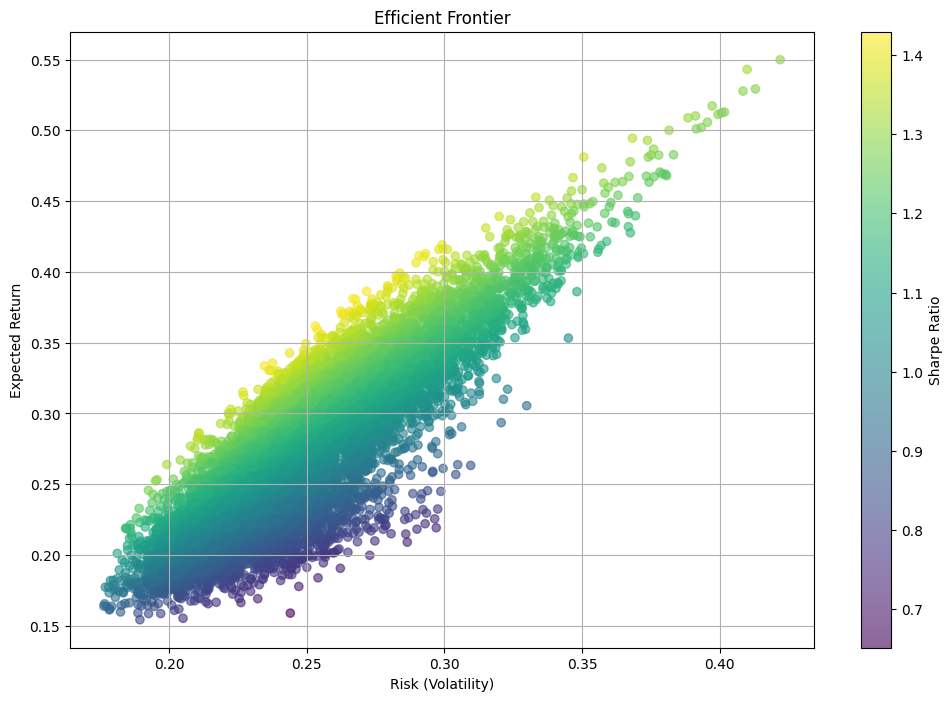

In [59]:
# 19.12.Plot the Efficient Frontier

plt.figure(figsize=(12,8))

scatter = plt.scatter(
    results_df["Risk"],
    results_df["Return"],
    c=results_df["Sharpe"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(scatter, label="Sharpe Ratio")

plt.xlabel("Risk (Volatility)")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier")

plt.grid(True)

plt.show()

In [60]:
# 19.13.Find The Optimal Portfolio

max_sharpe_idx = results_df["Sharpe"].idxmax()

optimal_weights = weights_record[max_sharpe_idx]

optimal_portfolio = pd.DataFrame({

    "Ticker": selected_tickers,
    "Optimal Weight": optimal_weights

})

optimal_portfolio

,Ticker,Optimal Weight
0,MSFT,0.034031
1,NVDA,0.490135
2,AMZN,0.065010
3,V,0.390758
4,JNJ,0.020066


In [61]:
# 19.14 Compare Equal Weight and Optimized Portfolio

comparison = pd.DataFrame({
    "Ticker": selected_tickers,
    "Equal Weight": np.repeat(
        1/len(selected_tickers),
        len(selected_tickers)
    ),
    "Optimized Weight": optimal_weights
})

comparison

,Ticker,Equal Weight,Optimized Weight
0,MSFT,0.2,0.034031
1,NVDA,0.2,0.490135
2,AMZN,0.2,0.065010
3,V,0.2,0.390758
4,JNJ,0.2,0.020066


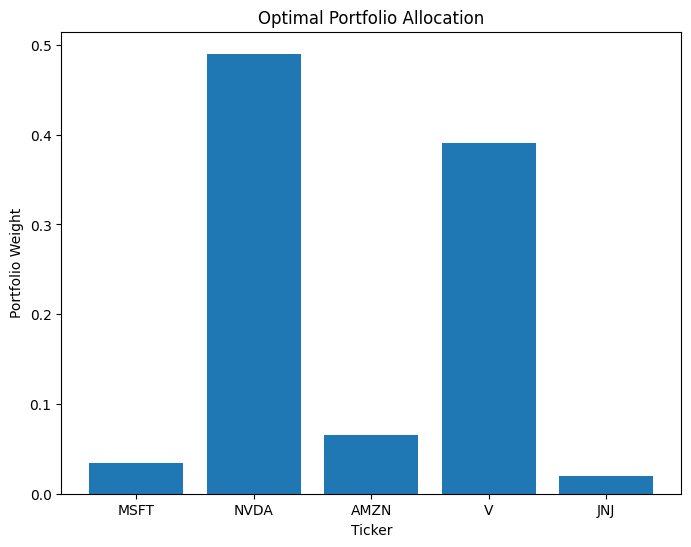

In [62]:
# 19.15.Plot Portfolio Allocation

plt.figure(figsize=(8,6))

plt.bar(
    comparison["Ticker"],
    comparison["Optimized Weight"]
)

plt.title("Optimal Portfolio Allocation")
plt.ylabel("Portfolio Weight")
plt.xlabel("Ticker")

plt.show()

In [63]:
# 19.16.Save Results

comparison.to_csv(
    "Outputs/mpt_optimal_weights.csv",
    index=False
)

results_df.to_csv(
    "Outputs/efficient_frontier_results.csv",
    index=False
)

## Conclusion

Modern Portfolio Theory was applied to optimize the portfolio using historical returns and the covariance matrix. Rather than assigning equal capital to each stock, the optimizer identified the allocation that maximized the Sharpe Ratio.

The results indicate that Visa (V) and Johnson & Johnson (JNJ) received the highest allocations due to their favorable balance between expected return and risk, while Meta (META) received a minimal allocation because of its comparatively weaker risk-adjusted performance during the selected time period.

This demonstrates how quantitative optimization can improve portfolio construction compared with equal-weight investing.

In [64]:
# 20.Monte Carlo Stimulation

## Objective

Monte Carlo Simulation estimates the possible future performance of the optimized portfolio by simulating thousands of potential market paths using historical return and volatility. This provides an understanding of the uncertainty and potential outcomes of an investment rather than relying on a single forecast.

In [65]:
# 20.1.Stimulation Parameters

# Number of simulations

num_simulations = 1000

# Number of trading days (1 year)

num_days = 252

initial_portfolio_value = investment_amount

print(num_simulations)
print(num_days)
print(initial_portfolio_value)

1000
252
100000


In [66]:
# 20.2.Portfolio Daily Returns

portfolio_daily_returns = (
    returns_df @ optimal_weights
)

portfolio_daily_returns.head()

Date
2020-01-03   -0.013311
2020-01-06    0.001659
2020-01-07    0.007149
2020-01-08    0.001779
2020-01-09    0.006860
dtype: float64

In [67]:
# 20.3.Estimate Mean and Standard Deviation

mu = portfolio_daily_returns.mean()

sigma = portfolio_daily_returns.std()

print("Daily Mean :", mu)

print("Daily Std :", sigma)

Daily Mean : 0.0014358129550131671
Daily Std : 0.015944109354516366


In [68]:
# 20.4.Generate Stimulation

simulation_df = pd.DataFrame()

for i in range(num_simulations):

    prices = [initial_portfolio_value]

    for j in range(num_days):

        daily_return = np.random.normal(
            mu,
            sigma
        )

        prices.append(
            prices[-1] * (1 + daily_return)
        )

    simulation_df[i] = prices

/var/folders/h1/n_brrnn95rbgjntwcswbttnw0000gn/T/ipykernel_65492/3518098205.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  simulation_df[i] = prices
/var/folders/h1/n_brrnn95rbgjntwcswbttnw0000gn/T/ipykernel_65492/3518098205.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  simulation_df[i] = prices
/var/folders/h1/n_brrnn95rbgjntwcswbttnw0000gn/T/ipykernel_65492/3518098205.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performa

/var/folders/h1/n_brrnn95rbgjntwcswbttnw0000gn/T/ipykernel_65492/3518098205.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  simulation_df[i] = prices
/var/folders/h1/n_brrnn95rbgjntwcswbttnw0000gn/T/ipykernel_65492/3518098205.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  simulation_df[i] = prices
/var/folders/h1/n_brrnn95rbgjntwcswbttnw0000gn/T/ipykernel_65492/3518098205.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performa

In [69]:
# 20.5.View Stimulation Data

simulation_df.head()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
1,100209.719866,98180.243514,99802.290614,99918.840849,99603.103178,99812.129950,101819.598312,99793.693669,101941.078779,99045.436971,...,99292.687436,101434.412941,100641.796195,101298.583038,101765.550294,100695.037033,100956.598824,99835.371800,101779.103580,99418.368812
2,101101.403163,98115.938367,101852.072315,100821.091696,100438.734846,101357.668498,102107.827330,97504.989321,100758.563567,99658.134431,...,100564.572260,104566.569283,98656.404681,99583.576043,103265.521619,98482.212810,100788.438403,100104.745390,100158.598424,96738.580753
3,102594.153904,98050.493969,103007.517401,101807.442802,100876.229936,103179.263260,101784.545160,98777.233848,103357.852380,99675.378053,...,101879.081568,103961.374101,99336.215285,99804.888668,103719.228903,97541.378356,103237.699427,99725.014199,98462.602179,97561.898966
4,102138.128227,97850.593568,104152.279589,102982.258619,103418.887342,103140.667495,103775.988364,100242.989564,105385.724534,100396.239340,...,99809.623680,105378.887409,102028.672295,99933.253490,104010.234988,97406.932679,104468.653245,100349.065558,97512.737030,98712.760701


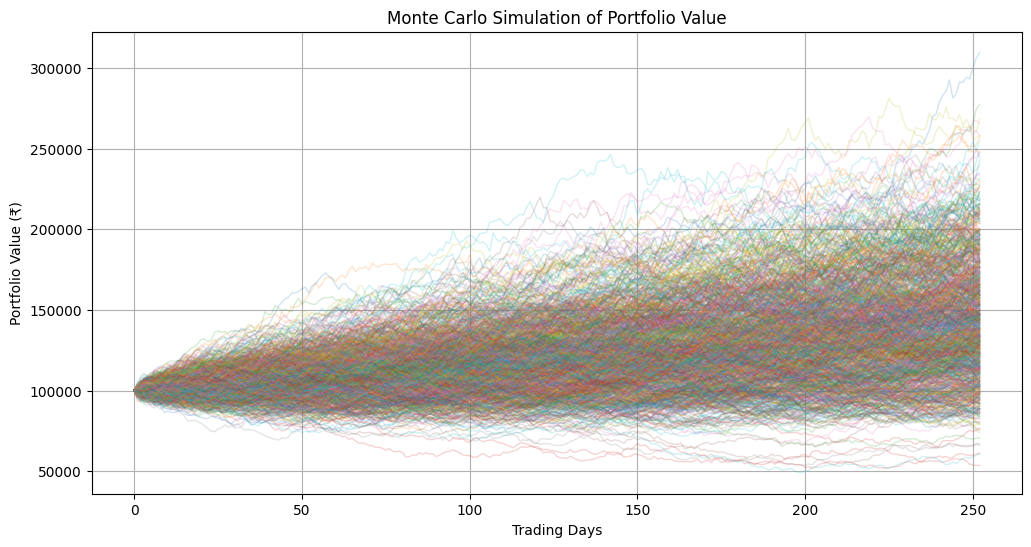

In [70]:
# 20.6.Plot Monte Carlo Stimulation

plt.figure(figsize=(12,6))

plt.plot(
    simulation_df,
    linewidth=1,
    alpha=0.2
)

plt.title("Monte Carlo Simulation of Portfolio Value")

plt.xlabel("Trading Days")

plt.ylabel("Portfolio Value (₹)")

plt.grid(True)

plt.show()

In [71]:
# 20.7.Distribution of Final Portfolio Values

final_values = simulation_df.iloc[-1]

final_values.describe()

count      1000.000000
mean     144636.044657
std       36953.584406
min       53696.436321
25%      117805.742939
50%      140833.598660
75%      166897.524889
max      309477.820977
Name: 252, dtype: float64

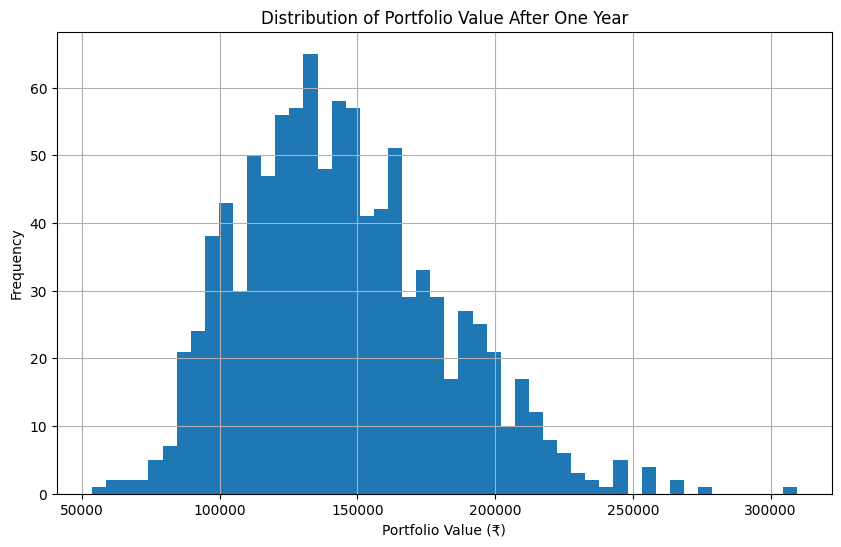

In [72]:
# 20.8.Plot Distribution

plt.figure(figsize=(10,6))

plt.hist(
    final_values,
    bins=50
)

plt.title("Distribution of Portfolio Value After One Year")

plt.xlabel("Portfolio Value (₹)")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [73]:
# 20.9.Calculate Percentile

percentiles = pd.DataFrame({

    "Percentile":[
        "5%",
        "50%",
        "95%"
    ],

    "Portfolio Value":[

        np.percentile(final_values,5),

        np.percentile(final_values,50),

        np.percentile(final_values,95)

    ]

})

percentiles

,Percentile,Portfolio Value
0,5%,92280.529666
1,50%,140833.598660
2,95%,211008.166944


In [74]:
# 20.10.Probability Of Profit

prob_profit = (

    final_values > initial_portfolio_value

).mean()

print(

    f"Probability of Profit: {prob_profit:.2%}"

)

Probability of Profit: 89.60%


In [75]:
# 20.12. Value at Risk 

VaR95 = initial_portfolio_value - np.percentile(
    final_values,
    5
)

print(

    f"95% Value at Risk: ₹{VaR95:,.2f}"

)

95% Value at Risk: ₹7,719.47


In [76]:
# 20.13.Consitional Value at Risk

CVaR95 = (

    initial_portfolio_value -

    final_values[
        final_values <= np.percentile(final_values,5)
    ].mean()

)

print(

    f"95% Conditional Value at Risk: ₹{CVaR95:,.2f}"

)

95% Conditional Value at Risk: ₹16,781.10


In [77]:
# 20.14.Save Results

percentiles.to_csv(
    "Outputs/monte_carlo_percentiles.csv",
    index=False
)

simulation_df.to_csv(
    "Outputs/monte_carlo_simulation.csv",
    index=False
)

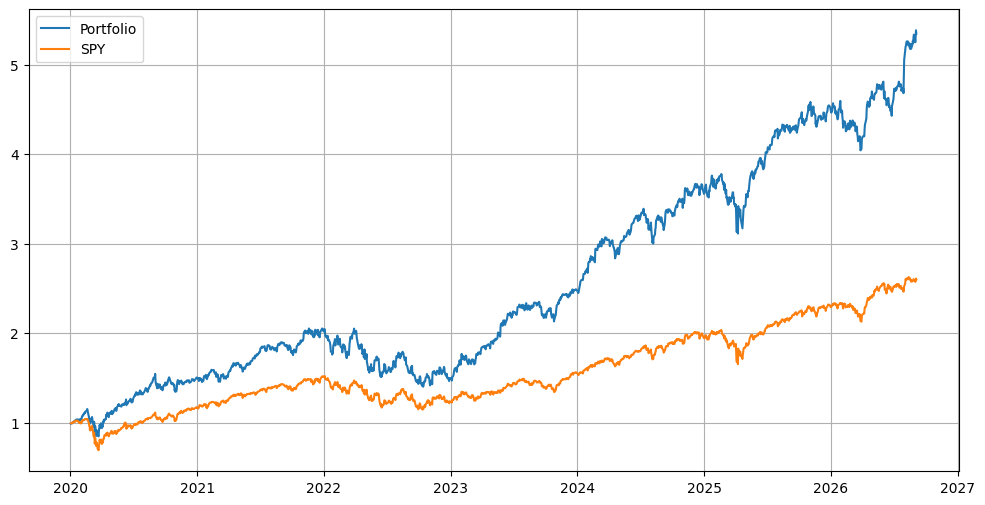

In [78]:
plt.figure(figsize=(12,6))

plt.plot(portfolio_growth, label="Portfolio")
plt.plot(benchmark_growth, label="SPY")

plt.legend()
plt.grid(True)

plt.savefig(
    "Outputs/portfolio_vs_benchmark.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()